In [4]:
import torch
import torch.distributions as td
import numpy as np
import matplotlib.pyplot as plt

import copy
import matplotlib.gridspec as gridspec
import time
from torch.nn.utils import clip_grad_norm_

In [5]:
class MoG():
    def __init__(self, means, covars, weights=None,
                 dtype=torch.float32, device='cpu'):
        """
        Class to handle operations around mixtures of multivariate
        Gaussian distributions
        Args:
            means: list of 1d tensors of centroids
            covars: list of 2d tensors of covariances
            weights: list of relative statistical weights (does not need to sum to 1)
        """
        self.device = device
        self.beta = 1.  # model 'temperature' for sampling with langevin and mh
        self.means = means
        self.covars = covars
        self.dim = means[0].shape[0]
        self.k = len(means)  # number of components in the mixture

        if weights is not None:
            self.weights = torch.tensor(weights, dtype=dtype, device=device)
        else:
            self.weights = torch.tensor([1 / self.k] * self.k,
                                        dtype=dtype, device=device)

        self.cs_distrib = td.categorical.Categorical(probs=self.weights)
        self.normal_distribs = []
        for c in range(self.k):
            c_distrib = td.multivariate_normal.MultivariateNormal(
                self.means[c].to(device),
                covariance_matrix=self.covars[c].to(device)
                )
            self.normal_distribs.append(c_distrib)

        self.covars_inv = torch.stack([torch.inverse(cv) for cv in covars])
        self.dets = torch.stack([torch.det(cv) for cv in covars])

    def sample(self, n):
        cs = self.cs_distrib.sample_n(n).to(self.device)

        samples = torch.zeros((n, self.dim), device=self.device)
        for c in range(self.k):
            n_c = (cs == c).sum()
            samples[cs == c, :] = self.normal_distribs[c].sample_n(n_c)
        return samples.to(self.device)

    def log_prob(self, x):
        x = x.unsqueeze(1)
        m = torch.stack(self.means).unsqueeze(0)
        args = - 0.5 * torch.einsum('kci,cij,kcj->kc', x-m, self.covars_inv, x-m)
        args += torch.log(self.weights)
        args -= torch.log((self.weights.sum() * torch.sqrt((2 * np.pi) ** self.dim * self.dets)))
        return  torch.logsumexp(args, 1)
    
    def U(self, x):
        x = x.unsqueeze(1)
        m = torch.stack(self.means).unsqueeze(0)
        args = - 0.5 * torch.einsum('kci,cij,kcj->kc', x-m, self.covars_inv, x-m)
        args += torch.log(self.weights)
        args -= torch.log((self.weights.sum() * torch.sqrt((2 * np.pi) ** self.dim * self.dets)))
        return - torch.logsumexp(args, 1)

    def grad_U(self, x_init):
        x = x_init.detach()
        x = x.requires_grad_()
        optimizer = torch.optim.SGD([x], lr=0)
        optimizer.zero_grad()
        loss = self.U(x).sum()
        loss.backward()
        return x.grad.data

sep = 2.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-1 * torch.eye(2)]
#shift_means = [torch.tensor([-sep*0.8, 0]), torch.tensor([sep, 0])]

target = MoG(means, covars, weights=[0.2, 0.8])
#prop = MoG(shift_means, covars)

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/torch/functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


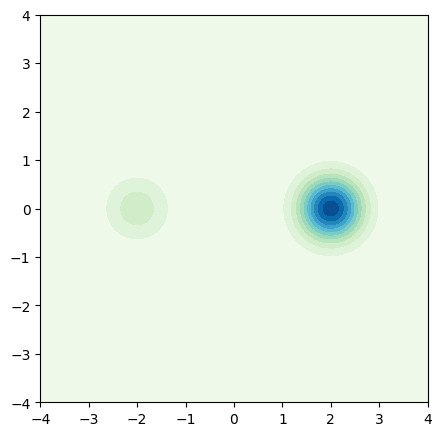

In [6]:
lims = {'x_min':-2 * sep, 'x_max':2 * sep, 'y_min':-2 * sep, 'y_max':2 * sep}
device = 'cpu'

def set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)


plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)

In [7]:
import torch
from flonacomldft.sampling import run_metropolis

In [8]:
n_samples = 10
target_samples = target.sample(n_samples)
target_samples

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/torch/distributions/distribution.py:159: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


tensor([[ 2.0439,  0.4021],
        [ 2.5508,  0.6148],
        [ 1.9738,  0.5395],
        [ 2.2820, -0.5449],
        [ 2.1100,  0.7448],
        [ 2.1555, -0.1924],
        [ 2.7585, -0.7372],
        [-2.4953, -0.1922],
        [ 2.4668, -0.2468],
        [ 1.3827,  0.3075]])

In [9]:
target_us = target.U(target_samples)
target_us

tensor([0.8607, 2.1548, 1.1810, 1.3928, 1.8685, 0.6046, 3.2485, 2.5435, 1.1486,
        1.6406])

In [10]:
id_mode = torch.zeros(n_samples)
id_mode

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [11]:
init = torch.cat([target_samples.T, target_us.reshape(1, -1), id_mode.reshape(1, -1)]).T
init

tensor([[ 2.0439,  0.4021,  0.8607,  0.0000],
        [ 2.5508,  0.6148,  2.1548,  0.0000],
        [ 1.9738,  0.5395,  1.1810,  0.0000],
        [ 2.2820, -0.5449,  1.3928,  0.0000],
        [ 2.1100,  0.7448,  1.8685,  0.0000],
        [ 2.1555, -0.1924,  0.6046,  0.0000],
        [ 2.7585, -0.7372,  3.2485,  0.0000],
        [-2.4953, -0.1922,  2.5435,  0.0000],
        [ 2.4668, -0.2468,  1.1486,  0.0000],
        [ 1.3827,  0.3075,  1.6406,  0.0000]])

In [12]:
from flonacomldft.models.real_nvp import RealNVP_MLP

In [13]:
n_blocks = 4
hidden_dim = 64
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-3,
                    base_cov=None,
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

In [14]:
from flonacomldft.train_flow_from_data import train_flow

In [15]:
n_samples = 10000

target_samples = target.sample(n_samples)
target_us = target.U(target_samples)
id_mode = torch.zeros(n_samples)

dataset = torch.cat([target_samples.T, target_us.reshape(1, -1), id_mode.reshape(1, -1)]).T
dataset

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/torch/distributions/distribution.py:159: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


tensor([[ 2.2898,  0.3443,  0.9579,  0.0000],
        [ 2.6902,  0.2883,  1.8503,  0.0000],
        [-1.4835,  0.3535,  2.8173,  0.0000],
        ...,
        [ 1.1505,  0.2559,  2.4192,  0.0000],
        [-2.1737,  0.1904,  2.0039,  0.0000],
        [-1.5985,  0.8519,  4.0554,  0.0000]])

In [16]:
train = dataset[:int(n_samples*0.8)]
test = dataset[int(n_samples*0.8):]

train.shape, test.shape

(torch.Size([8000, 4]), torch.Size([2000, 4]))

In [17]:
flow_dic = train_flow(
    model,
    train,
    test,
    dim=2,
    n_iter=1000,
    lr=1e-3,
    use_scheduler=False,
    step_schedule=int(100000/10),
    save_splits=10,
    grad_clip=1e4,
    with_tqdm=False,
)

t=0.0e+00 	 loss: 4.05	Gd: 2e+00	lr: 1.00e-03
t=1.0e+02 	 loss: 2.55	Gd: 3e-02	lr: 1.00e-03
t=2.0e+02 	 loss: 2.21	Gd: 2e-01	lr: 1.00e-03
t=3.0e+02 	 loss: 1.85	Gd: 8e-02	lr: 1.00e-03
t=4.0e+02 	 loss: 1.79	Gd: 4e-02	lr: 1.00e-03
t=5.0e+02 	 loss: 1.77	Gd: 5e-02	lr: 1.00e-03
t=6.0e+02 	 loss: 1.76	Gd: 6e-02	lr: 1.00e-03
t=7.0e+02 	 loss: 1.75	Gd: 1e-01	lr: 1.00e-03
t=8.0e+02 	 loss: 1.75	Gd: 2e-01	lr: 1.00e-03
t=9.0e+02 	 loss: 1.75	Gd: 2e-01	lr: 1.00e-03


In [17]:
init = init[:5]
init

tensor([[-1.7473, -0.4098,  0.8079,  0.0000],
        [-2.8263,  0.0884,  1.9550,  0.0000],
        [-1.3134, -0.0701,  1.4192,  0.0000],
        [-2.1886,  0.7541,  1.7391,  0.0000],
        [-1.4237, -0.6473,  2.1062,  0.0000]])

In [18]:
_ = run_metropolis(flow_dic['model'], init, 5, 100, dim=2, energy_type='mlp', mlp_models=target.U)

step: 0 	 acc: 0.40
step: 10 	 acc: 0.20
step: 20 	 acc: 0.00
step: 30 	 acc: 0.00
step: 40 	 acc: 0.00
step: 50 	 acc: 0.00
step: 60 	 acc: 0.00
step: 70 	 acc: 0.00
step: 80 	 acc: 0.00
step: 90 	 acc: 0.00


In [30]:
flow_samples = flow_dic['model'].sample(100)

In [18]:
fig, ax = plt.subplots(1,1, figsize=(5,7))
flowlogprob = lambda x: -flow_dic['model'].nll(x)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)
#plt.scatter(train[:,0].detach().numpy(), train[:,1].detach().numpy(), label='train')
#plt.scatter(test[:,0], test[:,1], label='test')
#plt.scatter(flow_samples[:,0].detach().numpy(), flow_samples[:,1].detach().numpy(), label='flow')
plt.legend()

: 

: 

In [ ]:
# use metropolis from flonaco, adapt for Gaussian mixture

In [39]:
# def run_metropolis(model, target, x_init, n_steps):
#     xs = []
#     accs = []
# 
#     for dt in range(n_steps):
#         x = model.sample(x_init.shape[0])
#         ratio = - target.beta * target.U(x) + model.nll(x)
#         ratio += target.beta * target.U(x_init) - model.nll(x_init)
#         ratio = torch.exp(ratio)
#         u = torch.rand_like(ratio)
#         acc = u < torch.min(ratio, torch.ones_like(ratio))
#         x[~acc] = x_init[~acc]
#         xs.append(x.clone())
#         accs.append(acc)
#         x_init = x.clone()
# 
#     return torch.stack(xs), torch.stack(accs)

In [43]:
#target_samples = target.sample(10)
#mcmc, accs = run_metropolis(model, target, target_samples, 100)

#plt.plot(accs.float().mean(1).detach().cpu().numpy())

In [44]:
def compute_ESS(x):
    """
    Patching to take convention of axis orders,
    and convert from torch to numpy
    x : (n_iter, m_chaines, dim)
    """
    try:
        x = x.detach().numpy()
    except AttributeError:
        x = x

    x = x.swapaxes(0, 1)
    return my_ESS(x)

def my_gelman_rubin(x):
    """
    Estimate the marginal posterior variance. Vectorised implementation.
    x : m_chaines, n_iter
    """
    m_chains, n_iter = x.shape

    # Calculate between-chain variance
    B_over_n = ((np.mean(x, axis=1) - np.mean(x))**2).sum() / (m_chains - 1)

    # Calculate within-chain variances
    W = ((x - x.mean(axis=1, keepdims=True)) **
         2).sum() / (m_chains * (n_iter - 1))

    # (over) estimate of variance
    s2 = W * (n_iter - 1) / n_iter + B_over_n

    return s2

def my_ESS(x):
    """
    Compute the effective sample size of estimand of interest.
    Vectorised implementation.
    x : m_chaines, n_iter, dim
    """
    if x.shape < (2,):
        raise ValueError(
            'Calculation of effective sample size'
            'requires multiple chains of the same length.')
    try:
        m_chains, n_iter = x.shape
    except ValueError:
        return [my_ESS(y.T) for y in x.T]

    def variogram(t): return (
        (x[:, t:] - x[:, :(n_iter - t)])**2).sum() / (m_chains * (n_iter - t))

    post_var = my_gelman_rubin(x)
    assert post_var > 0

    t = 1
    rho = np.ones(n_iter)
    negative_autocorr = False

    # Iterate until the sum of consecutive estimates of autocorrelation is negative
    while not negative_autocorr and (t < n_iter):
        rho[t] = 1 - variogram(t) / (2 * post_var)

        if not t % 2:
            negative_autocorr = sum(rho[t - 1:t + 1]) < 0

        t += 1

    return int(m_chains * n_iter / (1 + 2 * rho[1:t].sum()))

In [45]:
def compute_ESS(x):
    """
    Patching to take convention of axis orders,
    and convert from torch to numpy
    x : (n_iter, m_chaines, dim)
    """
    try:
        x = x.detach().numpy()
    except AttributeError:
        x = x

    x = x.swapaxes(0, 1)
    return my_ESS(x)

In [63]:
def run_mcmc_adapt(model, target, n_iter=10, lr=1e-1, bs=100,
          use_scheduler=False,
          step_schedule=10000,
          args_loss={'type': 'fwd', 'samp': 'direct'},
          estimate_tau=False,
          return_all_xs=True,
          save_splits=10,
          grad_clip=1e4):
    """"
    Main adpating/sampling function.

    Args:
        model (Realnvp_MLP)
        target (MoG, PhiFour)
        n_iter (int)
        lr (float): learning rate
        bs (int): batchsize
        use_scheduler (bool): if learning rate schedule should be used
        step_schedule (int): iteration frequency of schedule   
        args_loss (dict): 
                    'type' - loss type 'fwd', 'bwd', 'js'
                    'samp' - sampling method 'langevin', 'direct', 'mhlangevin' 
                    + kwargs for sampling method
                    Note that not all combinations are possible
                    depending on target etc.
        args_stop (dict): {'acc': x} with x in [0,1] Metropolis acceptance
                    threshold to stop train
        estimate_tau: estimates autocorrelation time
        return_all_xs: will return samples produced on the fly
        save_splits: number of snapshots saved during training
    """

    # setting up the loss
    def loss_func(x): return (model.nll(x) - target.U(x)).mean()

    # setting the sampling
    if 'langevin' in args_loss['samp']:
        ## setting initialization for chain methods
        skip_burnin = False
        assert args_loss['n_tot'] <= bs
        
        if args_loss['x_init_samp'] is not None:
            x_init = args_loss['x_init_samp'][-args_loss['n_tot']:]
            skip_burnin = True
        elif isinstance(target, MoG) or isinstance(target, Croissants):
            x_init = torch.stack(target.means)
            x_init = x_init.repeat_interleave(
                int(args_loss['n_tot'] / len(target.means)), dim=0)
        else:
            raise NotImplementedError("TODO: Implement init within target class")
        x_init = x_init.detach().requires_grad_()
        ## setting samplimg functions
        if args_loss['samp'] == 'mhmalangevin':
            def sample_func(bs, x_init=x_init, dt=100, beta=1, alpha=0, acc_rate=None):
                n_steps = int(bs / x_init.shape[0])
                x, acc = run_metromalangevin(
                    model, target, x_init, n_steps, dt * model.dim)
                kwargs['x_init'] = x[-1, ...].detach().requires_grad_()
                kwargs['acc_rate'] = (acc.cpu().numpy() * 1).mean()
                return x
    
        elif args_loss['samp'] == 'malangevin':
            def sample_func(bs, x_init=x_init, dt=100, beta=1, acc_rate=None):
                n_steps = int(bs / x_init.shape[0])
                x, acc = run_MALA(
                    target, x_init, n_steps, dt=dt * model.dim)
                kwargs['x_init'] = x[-1, ...].detach().requires_grad_()
                kwargs['acc_rate'] = (acc.cpu().numpy() * 1).mean()
                return x
        kwargs = {'x_init': x_init,
                  'dt': args_loss['dt'],
                  'beta': args_loss['beta']}
        if not skip_burnin:
            bs_burnin = int(args_loss['n_steps_burnin'] * x_init.shape[0])
            start = time.time()
            n_steps = int(bs_burnin / x_init.shape[0])
            x, _ = run_MALA(target, x_init, n_steps, args_loss['dt'] * model.dim)
            kwargs['x_init'] = x[-1, ...].detach().requires_grad_()
            print('MALA burnin done! time: {:f}s'.format(time.time() - start))
 
    if args_loss['samp'] == 'direct':
        def sample_func(bs):
            return target.sample(bs)
        
    assert sample_func is not None
 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 
                                                    step_size=step_schedule, 
                                                    gamma=0.5)

    fig = plt.figure(figsize=(15, 5))
    gs = gridspec.GridSpec(2, 5)
    axs = [fig.add_subplot(gs[a]) for a in range(10)]
    a = 0  # counter index for axs

    # logs
    xs = []
    losses = []
    models = [copy.deepcopy(model)]
    taus = []
    acc_rates = []
    acc_rates_mala = []
    grad_norms = []

    for t in range(n_iter):
        optimizer.zero_grad()

        x_ = sample_func(bs)

        x = x_.reshape(-1, model.dim).detach().requires_grad_()
        loss = loss_func(x)
        if args_loss['samp'] == 'langevin_action':
            loss = loss * target.dt * target.beta

        if return_all_xs or t % (n_iter / 10) == 0:
            xs.append(x_)

        if torch.isinf(loss).any():
            print('Stopped because loss became inf!')
            return model, losses, xs

        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()


        #logs
        losses.append(loss.item())

        if t % (n_iter / 100) == 0:
            total_norm = 0
            for p in model.parameters():
                param_norm = p.grad.detach().data.norm(2)
                total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5 
            grad_norms.append(total_norm)

        if use_scheduler:
            scheduler.step()

        if estimate_tau:
            tau = x.shape[0] * x.shape[1] / \
                np.mean(compute_ESS(x.detach().cpu()))
            taus.append(tau)

        x_last = x.clone()
        _, acc = run_metropolis(model, target, x_last, 1)
        acc_rate = (acc.cpu().numpy() * 1).mean()
        acc_rates.append(acc_rate.item())
        #_, acc = run_MALA(target, x_last, 1,  dt=args_loss['dt'] * model.dim)
        #acc_rate = (acc.cpu().numpy() * 1).mean()
        #acc_rates_mala.append(acc_rate.item())

        #prints
        if t % (n_iter / save_splits) == 0 or n_iter <= save_splits:
            models.append(copy.deepcopy(model))
            print('t={:0.1e}'.format(t),
                  'Loss: {:3.2f}'.format(loss.item()), end='  \t')

            #print('mh acc: {:0.2e}, mala acc: {:0.2e}'.format(acc_rates[-1],
            #                                          acc_rates_mala[-1]),
            #                                          end='\t')
            
            print('acc: {:0.2e}'.format(acc_rates[-1]), end='\t')

            print('Gd: {:0.0e}'.format(total_norm), end='\t')

            for param_group in optimizer.param_groups:
                print('lr: {:0.2e}'.format(param_group['lr']), end='\t')

            print('')

        if t % (n_iter / 10) == 0:
            if model.dim == 2:
                #assert isinstance(target, MoG) or isinstance(target, Croissants)
                #x_min = -10 if isinstance(target, MoG) else -0.5
                #x_max = 10 if isinstance(target, MoG) else 0.5
                #flonacomldft.gaussian_utils.plot_2d_level(model, ax=axs[a],
                #                                    title='t= ' + str(t),
                #                                    x_min=x_min, x_max=x_max)

                plt.scatter(x[:, 0].detach().cpu(),
                            x[:, 1].detach().cpu(), s=1., alpha=0.1)

            plt.tight_layout()
            a += 1  # update counter of axes to plots

    to_return = {
        'model': model,
        'losses': losses,
        'xs': xs,
        'models': models,
        'taus': taus,
        'acc_rates': acc_rates,
        'acc_rates_mala': acc_rates_mala,
        'grad_norms': grad_norms,
    }

    return to_return

In [69]:
from flonacomldft.models.real_nvp import RealNVP_MLP

In [73]:
n_blocks = 2
hidden_dim = 8
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-3,
                    base_cov=None,
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

t=0.0e+00 Loss: 2.75  	acc: 5.00e-02	Gd: 3e+00	lr: 1.00e-04	
t=1.0e+02 Loss: 2.62  	acc: 5.00e-02	Gd: 3e+00	lr: 1.00e-04	
t=2.0e+02 Loss: 2.56  	acc: 5.00e-02	Gd: 2e+00	lr: 1.00e-04	
t=3.0e+02 Loss: 2.58  	acc: 4.00e-02	Gd: 3e+00	lr: 1.00e-04	
t=4.0e+02 Loss: 2.50  	acc: 4.00e-02	Gd: 2e+00	lr: 1.00e-04	
t=5.0e+02 Loss: 2.48  	acc: 5.00e-02	Gd: 2e+00	lr: 1.00e-04	
t=6.0e+02 Loss: 2.22  	acc: 6.00e-02	Gd: 2e+00	lr: 1.00e-04	
t=7.0e+02 Loss: 1.82  	acc: 1.10e-01	Gd: 2e+00	lr: 1.00e-04	
t=8.0e+02 Loss: 1.99  	acc: 1.60e-01	Gd: 2e+00	lr: 1.00e-04	
t=9.0e+02 Loss: 1.70  	acc: 1.40e-01	Gd: 2e+00	lr: 1.00e-04	


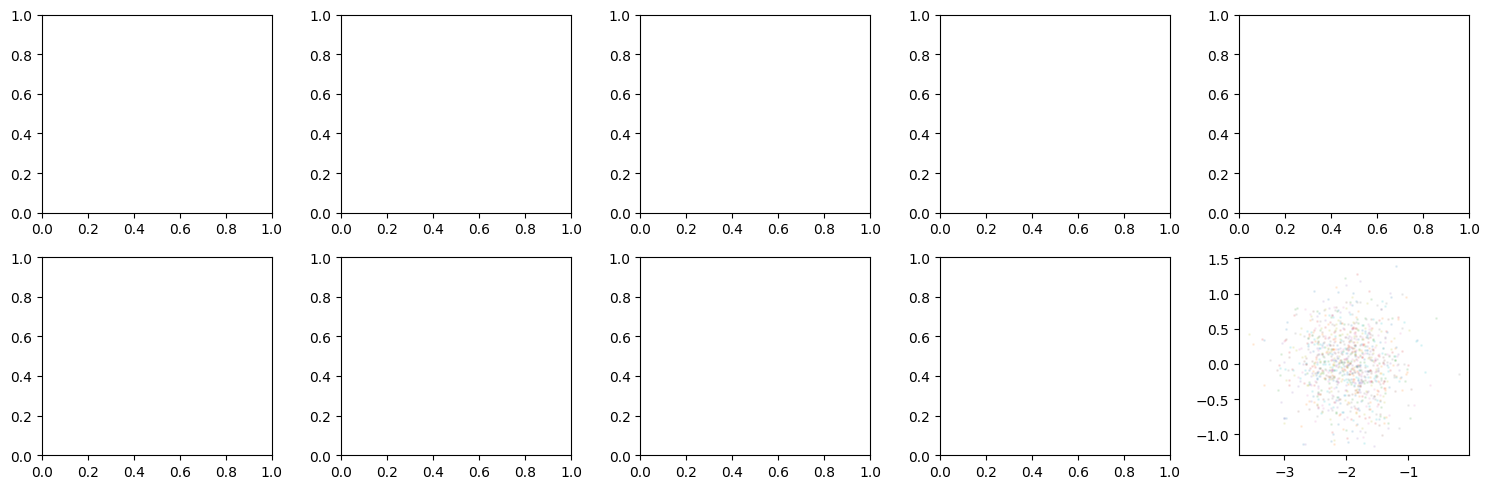

In [74]:
_ = run_mcmc_adapt(model, target, n_iter=1000, lr=1e-4, bs=100,
          use_scheduler=False,
          step_schedule=100,
          args_loss={'type': 'fwd', 'samp': 'direct'},
          estimate_tau=False,
          return_all_xs=True,
          save_splits=10,
          grad_clip=1e4)

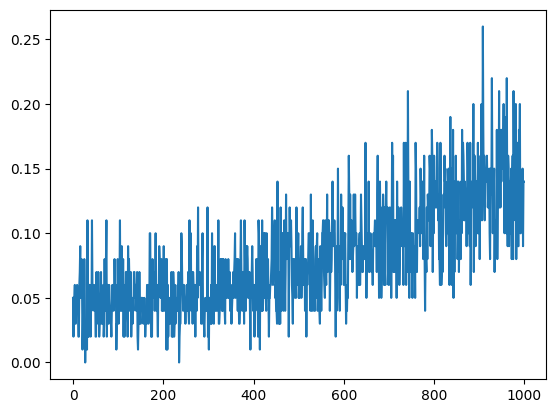

In [75]:
plt.plot(_['acc_rates'])